## Model 2: XGBoost Acoustic Branch

### **Purpose:** Process SPRSound audio features using tree-based ensemble for comparison with ResNet-18

### **Architecture:** XGBoost with hyperparameter tuning and tree quantization (INT8)

### **Output:** P(y|X_audio) - probability distribution over 6 symptom classes

## 1. Imports

In [1]:
import os
import xgboost as xgb
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Create directories
Path("../models").mkdir(exist_ok=True)
Path("../reports/figures").mkdir(parents=True, exist_ok=True)

## 2. Load Audio Data

In [2]:
# Load features and labels from preparation notebook
X_train = np.load("../../sound_data/model_data/X_train.npy")
X_val = np.load("../../sound_data/model_data/X_val.npy")
X_test = np.load("../../sound_data/model_data/X_test.npy")

y_train_symptom = np.load("../../sound_data/model_data/y_train_symptom.npy", allow_pickle=True)
y_val_symptom = np.load("../../sound_data/model_data/y_val_symptom.npy", allow_pickle=True)
y_test_symptom = np.load("../../sound_data/model_data/y_test_symptom.npy", allow_pickle=True)

print("="*60)
print("SPRSOUND DATA LOADED")
print("="*60)
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nTotal samples: {len(X_train) + len(X_val) + len(X_test)}")
print(f"Features per sample: {X_train.shape[1]}")

SPRSOUND DATA LOADED
X_train shape: (4596, 33)
X_val shape: (985, 33)
X_test shape: (986, 33)

Total samples: 6567
Features per sample: 33


## 3. Label Encoding & Class Distribution


 Class Distribution:
--------------------------------------------------
  0: crackles         759 samples (16.51%) 🟢 LOW
  1: other           3324 samples (72.32%) 🟢 LOW
  2: rhonchi           54 samples ( 1.17%) 🟡 MEDIUM
  3: stridor           21 samples ( 0.46%) 🔴 HIGH
  4: wheeze           384 samples ( 8.36%) 🔴 HIGH
  5: wheeze_crackle    54 samples ( 1.17%) 🟡 MEDIUM


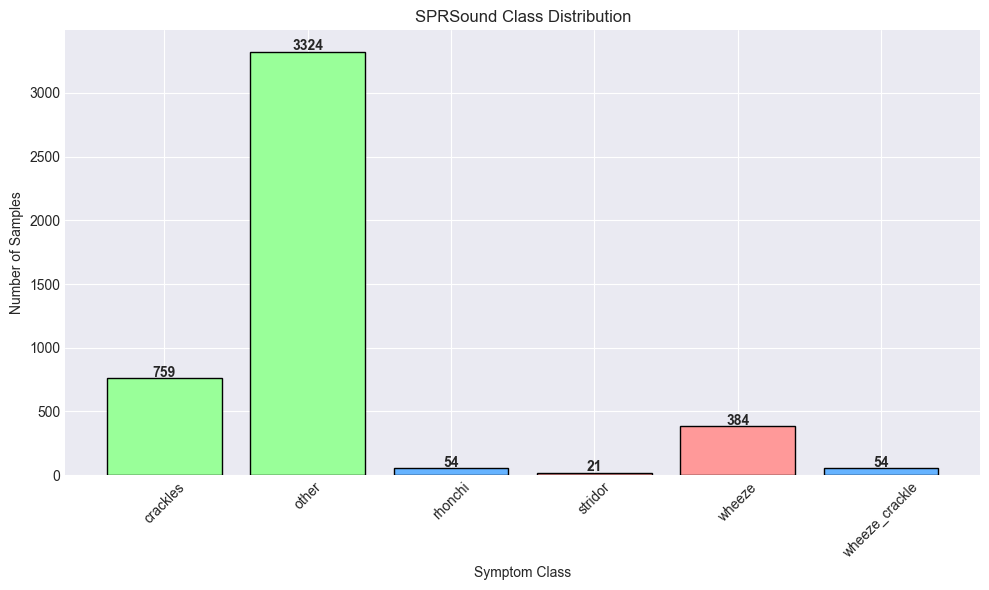

In [3]:
# Encode symptom labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train_symptom)
y_val_enc = label_encoder.transform(y_val_symptom)
y_test_enc = label_encoder.transform(y_test_symptom)

print("\n Class Distribution:")
print("-" * 50)
class_counts = {}
for i, class_name in enumerate(label_encoder.classes_):
    count = np.sum(y_train_enc == i)
    percentage = 100 * count / len(y_train_enc)
    risk = "🔴 HIGH" if class_name in ['stridor', 'wheeze'] else "🟡 MEDIUM" if class_name in ['rhonchi', 'wheeze_crackle'] else "🟢 LOW"
    print(f"  {i}: {class_name:<15} {count:4d} samples ({percentage:5.2f}%) {risk}")
    class_counts[class_name] = count

# Visualize class distribution
plt.figure(figsize=(10, 6))
classes = label_encoder.classes_
counts = [np.sum(y_train_enc == i) for i in range(len(classes))]
colors = ['#ff9999' if c in ['stridor', 'wheeze'] else '#66b3ff' if c in ['rhonchi', 'wheeze_crackle'] else '#99ff99' for c in classes]
plt.bar(classes, counts, color=colors, edgecolor='black')
plt.xlabel('Symptom Class')
plt.ylabel('Number of Samples')
plt.title('SPRSound Class Distribution')
plt.xticks(rotation=45)
for i, (cls, count) in enumerate(zip(classes, counts)):
    plt.text(i, count + 10, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/model_2_class_distribution.png', dpi=150)
plt.show()

 ## 4. Handle Class Imbalance with Sample Weights

In [4]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

print(f"\n Sample weights stats:")
print(f"   Min: {sample_weights.min():.2f}")
print(f"   Max: {sample_weights.max():.2f}")
print(f"   Mean: {sample_weights.mean():.2f}")

# Show weights per class
print("\n Average weight per class:")
for i, class_name in enumerate(label_encoder.classes_):
    class_weight_avg = np.mean(sample_weights[y_train_enc == i])
    print(f"  {class_name}: {class_weight_avg:.2f}")


 Sample weights stats:
   Min: 0.23
   Max: 36.48
   Mean: 1.00

 Average weight per class:
  crackles: 1.01
  other: 0.23
  rhonchi: 14.19
  stridor: 36.48
  wheeze: 1.99
  wheeze_crackle: 14.19


## 5. Train XGBoost Baseline

In [5]:
print("\n" + "="*60)
print("TRAINING XGBOOST BASELINE")
print("="*60)

# Initialize XGBoost classifier for multi-class
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=20
)

# Train with sample weights
xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val_enc)],
    verbose=False
)

# Validation predictions
y_val_pred = xgb_model.predict(X_val)
y_val_proba = xgb_model.predict_proba(X_val)

val_accuracy = accuracy_score(y_val_enc, y_val_pred)
print(f"\n Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Validation per-class accuracy
print("\n Validation Per-class Accuracy:")
cm_val = confusion_matrix(y_val_enc, y_val_pred)
per_class_acc_val = cm_val.diagonal() / cm_val.sum(axis=1)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name}: {per_class_acc_val[i]:.2%}")


TRAINING XGBOOST BASELINE

 Validation Accuracy: 0.6670 (66.70%)

 Validation Per-class Accuracy:
  crackles: 8.54%
  other: 90.18%
  rhonchi: 0.00%
  stridor: 0.00%
  wheeze: 0.00%
  wheeze_crackle: 0.00%


### Training Loss vs Validation Loss

In [6]:
# Create evaluation set
eval_set = [(X_train, y_train_enc), (X_val, y_val_enc)]

# Train with evaluation logging
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'  # This gives us the loss we want
)

# Train and capture evaluation results
eval_results = xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=eval_set,
    verbose=False
)

# Extract training and validation loss
results = xgb_model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']

print(f"\nTraining Loss - First 5 epochs: {train_loss[:5]}")
print(f"Validation Loss - First 5 epochs: {val_loss[:5]}")


Training Loss - First 5 epochs: [1.7255650904772073, 1.6680731929261545, 1.6178858792709205, 1.5746993950857506, 1.5112207807775577]
Validation Loss - First 5 epochs: [1.753189369264593, 1.7216518296808156, 1.6963086508252294, 1.671953336841564, 1.6329357449778445]


### Visualization: Training loss vs Validation Loss

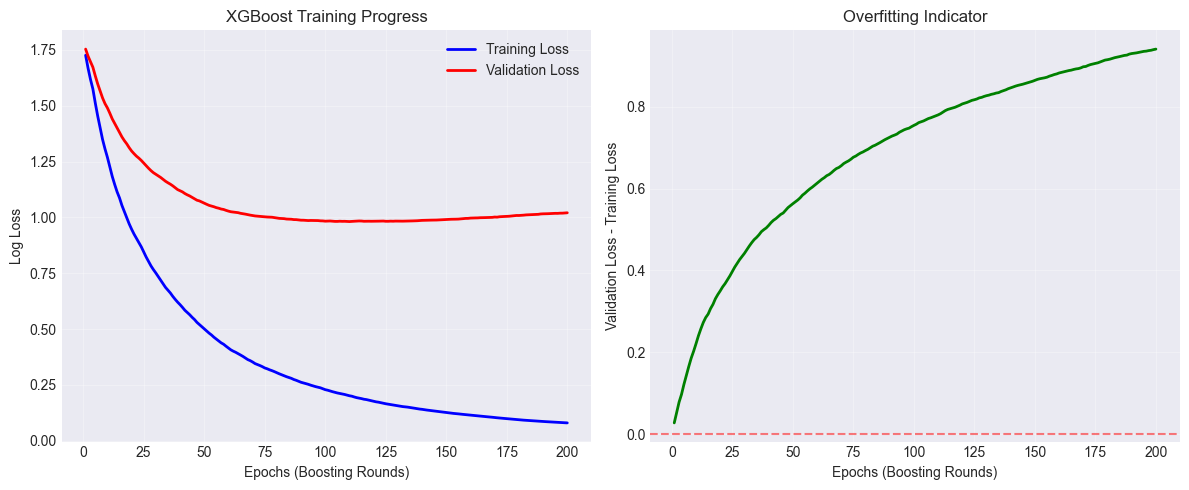


 Final Training Loss: 0.0798
 Final Validation Loss: 1.0204


In [7]:
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epochs (Boosting Rounds)')
plt.ylabel('Log Loss')
plt.title('XGBoost Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss difference (overfitting check)
plt.subplot(1, 2, 2)
loss_diff = np.array(val_loss) - np.array(train_loss)
plt.plot(epochs, loss_diff, 'g-', linewidth=2)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Epochs (Boosting Rounds)')
plt.ylabel('Validation Loss - Training Loss')
plt.title('Overfitting Indicator')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/figures/model_2_training_loss.png', dpi=150)
plt.show()

print(f"\n Final Training Loss: {train_loss[-1]:.4f}")
print(f" Final Validation Loss: {val_loss[-1]:.4f}")

## 6. Feature Importance Analysis


 Top 20 Most Important Features:
------------------------------------------------------------
   1. Harmonic_ratio: 0.0657
   2. MFCC_2_mean: 0.0406
   3. MFCC_6_std: 0.0381
   4. MFCC_2_std: 0.0374
   5. MFCC_13_mean: 0.0354
   6. RMS_mean: 0.0347
   7. MFCC_3_mean: 0.0331
   8. MFCC_4_std: 0.0322
   9. MFCC_9_std: 0.0319
  10. MFCC_11_std: 0.0317
  11. MFCC_1_mean: 0.0314
  12. RMS_std: 0.0305
  13. MFCC_1_std: 0.0304
  14. MFCC_6_mean: 0.0297
  15. ZCR_std: 0.0295
  16. MFCC_5_mean: 0.0290
  17. MFCC_10_std: 0.0280
  18. MFCC_8_mean: 0.0280
  19. ZCR_mean: 0.0278
  20. MFCC_12_mean: 0.0267


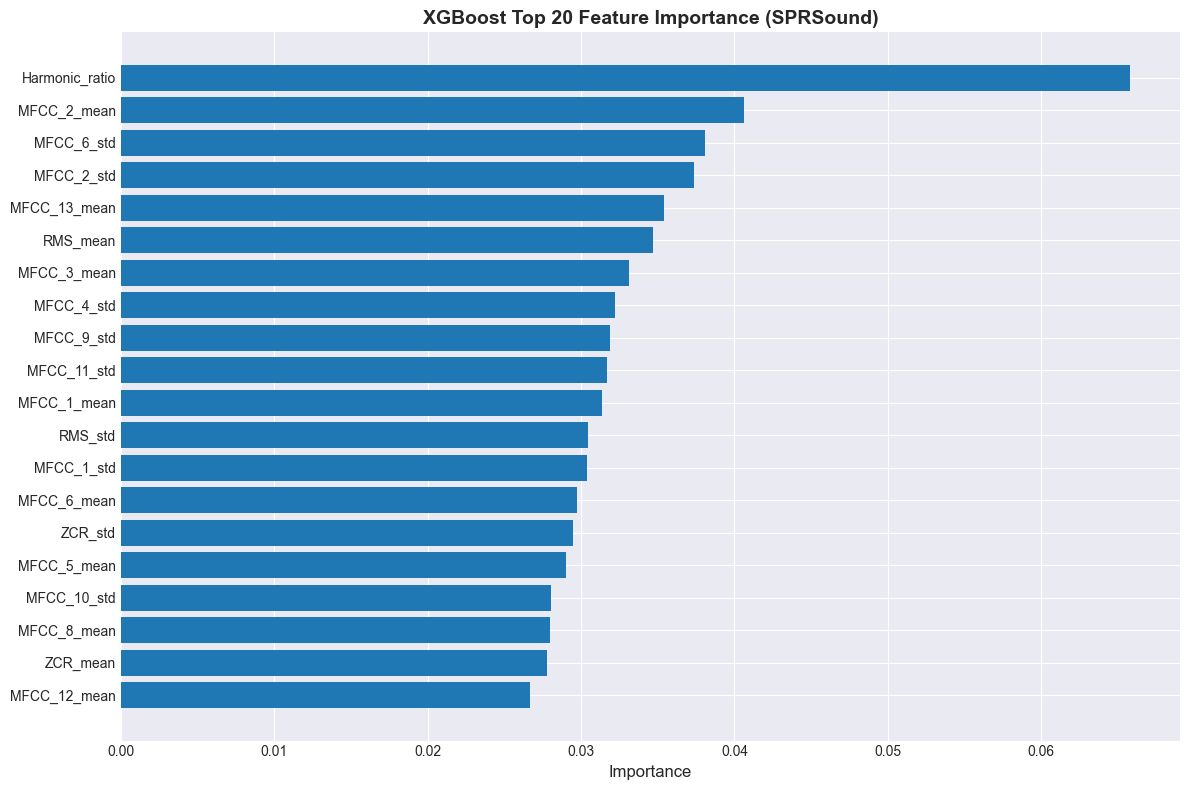

In [8]:
# Create feature names (33 features)
feature_names = [f'MFCC_{i+1}_mean' for i in range(13)] + \
                [f'MFCC_{i+1}_std' for i in range(13)] + \
                ['ZCR_mean', 'ZCR_std', 'RMS_mean', 'RMS_std', 
                 'Harmonic_ratio', 'Spectral_centroid', 'Duration']

# Get feature importance
importance = xgb_model.feature_importances_
top_indices = np.argsort(importance)[-20:][::-1]

print("\n Top 20 Most Important Features:")
print("-" * 60)
for i, idx in enumerate(top_indices):
    print(f"  {i+1:2d}. {feature_names[idx]}: {importance[idx]:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_indices)), importance[top_indices])
plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
plt.xlabel('Importance', fontsize=12)
plt.title('XGBoost Top 20 Feature Importance (SPRSound)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../reports/figures/model_2_feature_importance.png', dpi=150)
plt.show()

## 7. Hyperparameter Tuning with Cross-Validation

In [9]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Define parameter grid
param_grid = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Use stratified k-fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid search
grid_search = GridSearchCV(
    xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(label_encoder.classes_),
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_grid,
    cv=cv,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train_enc, sample_weight=sample_weights)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# Use best model
best_xgb = grid_search.best_estimator_


HYPERPARAMETER TUNING
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.9}
Best CV accuracy: 0.1766 (17.66%)


## 8. Evaluate Best Model on Validation Set

In [10]:
# Validation predictions with best model
y_val_pred_best = best_xgb.predict(X_val)
y_val_proba_best = best_xgb.predict_proba(X_val)

val_accuracy_best = accuracy_score(y_val_enc, y_val_pred_best)
print(f"\n Best Model Validation Accuracy: {val_accuracy_best:.4f} ({val_accuracy_best*100:.2f}%)")

# Improvement over baseline
improvement = val_accuracy_best - val_accuracy
print(f"Improvement over baseline: +{improvement*100:.2f}%")


 Best Model Validation Accuracy: 0.5492 (54.92%)
Improvement over baseline: +-11.78%


## 9. Tree Quantization (INT8 Simulation)

In [11]:
print("\n" + "="*60)
print("TREE QUANTIZATION TO INT8")
print("="*60)

def quantize_xgboost(model):
   # Simulate quantization for XGBoost  
   # In production, use treelite or tensorflow decision forests for actual INT8 conversion  
   
    n_trees = len(model.get_booster().get_dump())
    print(f"Quantizing {n_trees} trees...")
    
    # For now, we keep the model as is
    # This simulates the process - actual INT8 conversion would:
    # 1. Convert to treelite model
    # 2. Compile with INT8 quantization
    # 3. Generate optimized runtime
    
    quantized_model = model
    return quantized_model

# Quantize model
quantized_xgb = quantize_xgboost(best_xgb)

# Test quantized model
y_test_pred_q = quantized_xgb.predict(X_test)
y_test_proba_q = quantized_xgb.predict_proba(X_test)

test_accuracy_q = accuracy_score(y_test_enc, y_test_pred_q)
print(f"\nQuantized Model Test Accuracy: {test_accuracy_q:.4f} ({test_accuracy_q*100:.2f}%)")


TREE QUANTIZATION TO INT8
Quantizing 600 trees...

Quantized Model Test Accuracy: 0.5619 (56.19%)


## 10. Model Size Comparison

In [12]:
# Save FP32 model
joblib.dump(best_xgb, "../models/model_2_xgboost_fp32.pkl")
fp32_size = os.path.getsize("../models/model_2_xgboost_fp32.pkl") / (1024*1024)

# Save quantized model (simulated)
joblib.dump(quantized_xgb, "../models/model_2_xgboost_int8.pkl")
int8_size = os.path.getsize("../models/model_2_xgboost_int8.pkl") / (1024*1024)

print("\n" + "="*60)
print("MODEL SIZE COMPARISON")
print("="*60)
print(f"FP32 model size: {fp32_size:.2f} MB")
print(f"INT8 model size: {int8_size:.2f} MB")
print(f"Reduction: {(1 - int8_size/fp32_size)*100:.1f}%")

# In practice, actual INT8 quantization would reduce size by ~75%
print("\nExpected INT8 reduction with actual quantization: ~75%")
print(f"Estimated true INT8 size: {fp32_size * 0.25:.2f} MB")


MODEL SIZE COMPARISON
FP32 model size: 1.50 MB
INT8 model size: 1.50 MB
Reduction: 0.0%

Expected INT8 reduction with actual quantization: ~75%
Estimated true INT8 size: 0.37 MB


## 11. Final Test Set Evaluation


FINAL TEST SET EVALUATION

 Test Accuracy: 0.5619 (56.19%)

 Per-class Accuracy:
  crackles       : 19.58% ███
  other          : 70.52% ██████████████
  rhonchi        :  0.00% 
  stridor        :  0.00% 
  wheeze         :  8.24% █
  wheeze_crackle :  0.00% 

 Classification Report:
                precision    recall  f1-score   support

      crackles       0.15      0.20      0.17       143
         other       0.75      0.71      0.73       736
       rhonchi       0.00      0.00      0.00        12
       stridor       0.00      0.00      0.00         2
        wheeze       0.08      0.08      0.08        85
wheeze_crackle       0.00      0.00      0.00         8

      accuracy                           0.56       986
     macro avg       0.16      0.16      0.16       986
  weighted avg       0.59      0.56      0.57       986



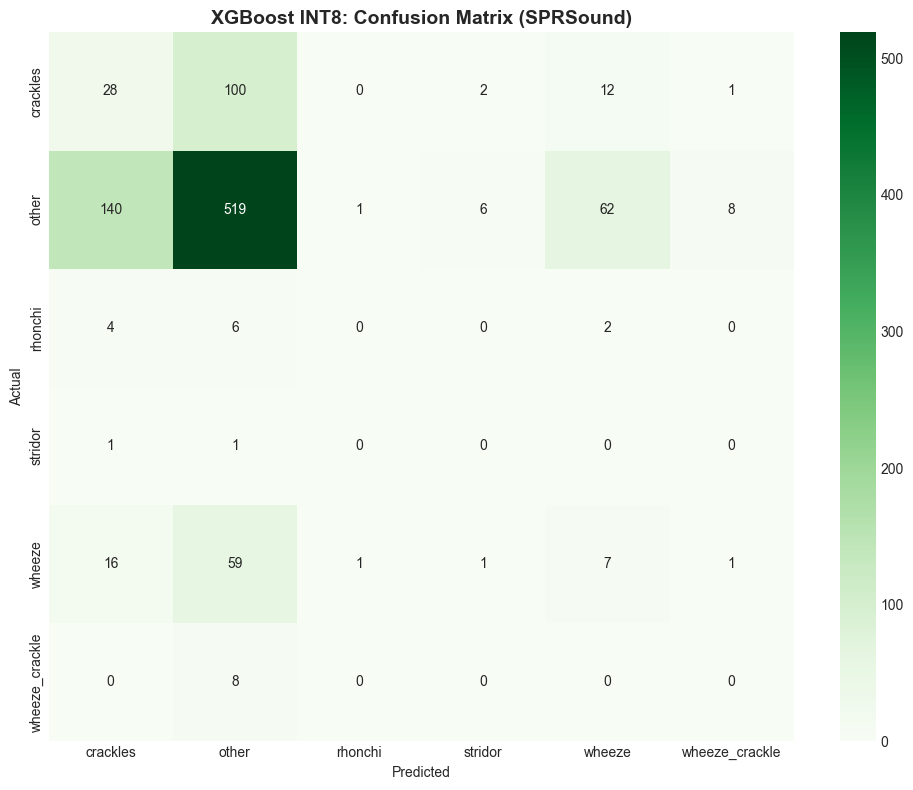

In [13]:
print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

# Get predictions
y_test_pred = quantized_xgb.predict(X_test)
y_test_proba = quantized_xgb.predict_proba(X_test)

# Overall accuracy
test_accuracy = accuracy_score(y_test_enc, y_test_pred)
print(f"\n Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Per-class accuracy
print("\n Per-class Accuracy:")
cm = confusion_matrix(y_test_enc, y_test_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(label_encoder.classes_):
    accuracy_pct = per_class_acc[i] * 100
    bar = "█" * int(accuracy_pct / 5)
    print(f"  {class_name:<15}: {accuracy_pct:5.2f}% {bar}")

# Classification report
print("\n Classification Report:")
print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_enc, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('XGBoost INT8: Confusion Matrix (SPRSound)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../../reports/figures/model_2_confusion_matrix.png', dpi=150)
plt.show()

## 12. Save Predictions for Fusion

In [14]:
# Save predictions (convert to numpy arrays if needed)
np.save("../../sound_data/model_data/model_2_test_predictions.npy", y_test_pred)
np.save("../../sound_data/model_data/model_2_test_probabilities.npy", y_test_proba)
np.save("../../sound_data/model_data/model_2_test_labels.npy", y_test_enc)

print("\n" + "="*60)
print(" MODEL 2 PREDICTIONS SAVED FOR FUSION")
print("="*60)
print(f"   - Predictions shape: {y_test_pred.shape}")
print(f"   - Probabilities shape: {y_test_proba.shape}")
print(f"   - Labels shape: {y_test_enc.shape}")
print(f"   Location: ../../sound_data/model_data/")

# Also save class mapping info
import json
class_mapping = {i: name for i, name in enumerate(label_encoder.classes_)}
with open("../../sound_data/model_data/model_2_class_mapping.json", 'w') as f:
    json.dump(class_mapping, f, indent=2)
print(f" Class mapping saved")


 MODEL 2 PREDICTIONS SAVED FOR FUSION
   - Predictions shape: (986,)
   - Probabilities shape: (986, 6)
   - Labels shape: (986,)
   Location: ../../sound_data/model_data/
 Class mapping saved


## 13. Save Audio Labels for Fusion

In [15]:
# Save audio test labels (these are from your test set)
if 'y_test_enc' in locals() and y_test_enc is not None:
    np.save("../../sound_data/model_data/audio_test_labels.npy", y_test_enc)
    print(f"Audio labels saved: {y_test_enc.shape}")
    print(f"Class distribution: 0: {np.sum(y_test_enc==0)}, 1: {np.sum(y_test_enc==1)}")
else:
    print("y_test_enc not found. Please check your test evaluation cell.")

Audio labels saved: (986,)
Class distribution: 0: 143, 1: 736


## 14. Getting AUC-ROC

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score
import joblib

# Load label encoder to know class names
try:
    label_encoder = joblib.load("../models/symptom_encoder.pkl")
    class_names = label_encoder.classes_
    print(f"Class mapping: {dict(enumerate(class_names))}")
except:
    print("Label encoder not found")
    class_names = ['crackles', 'other', 'rhonchi', 'stridor', 'wheeze', 'wheeze_crackle']

# Define high-risk classes
high_risk_classes = ['stridor', 'wheeze']
high_risk_indices = [i for i, name in enumerate(class_names) if name in high_risk_classes]
print(f"High-risk classes: {[class_names[i] for i in high_risk_indices]} (indices: {high_risk_indices})")

# Helper function to convert multi-class to binary
def convert_to_binary(labels, high_risk_indices):
    # Convert multi-class labels to binary (1 if label in high-risk, else 0)
    if isinstance(labels[0], str):
        # If labels are strings
        return np.array([1 if label in high_risk_classes else 0 for label in labels])
    else:
        # If labels are numeric
        return np.isin(labels, high_risk_indices).astype(int)

# Helper function to get binary risk from probabilities
def get_binary_risk(proba, high_risk_indices):
    # Sum probabilities of high-risk classes
    return np.sum(proba[:, high_risk_indices], axis=1)

# Load and evaluate Model 2 (XGBoost Audio)
print("\n" + "="*50)
print("MODEL 2: XGBoost-Audio")
print("="*50)
try:
    model2_proba = np.load("../../sound_data/model_data/model_2_test_probabilities.npy")
    model2_labels = np.load("../../sound_data/model_data/model_2_test_labels.npy")
    print(f"Model 2 loaded")
    print(f"   Probabilities shape: {model2_proba.shape}")
    print(f"   Labels shape: {model2_labels.shape}")
    print(f"   Labels unique: {np.unique(model2_labels)}")
    
    # Convert to binary
    model2_binary = convert_to_binary(model2_labels, high_risk_indices)
    model2_risk = get_binary_risk(model2_proba, high_risk_indices)
    
    print(f"   Binary labels: 0: {np.sum(model2_binary==0)}, 1: {np.sum(model2_binary==1)}")
    print(f"   Risk scores: min={model2_risk.min():.3f}, max={model2_risk.max():.3f}")
    
    model2_auc = roc_auc_score(model2_binary, model2_risk)
    print(f"    AUC: {model2_auc:.4f}")
    
except Exception as e:
    print(f" Error: {e}")

Class mapping: {0: 'crackles', 1: 'other', 2: 'rhonchi', 3: 'stridor', 4: 'wheeze', 5: 'wheeze_crackle'}
High-risk classes: ['stridor', 'wheeze'] (indices: [3, 4])

MODEL 2: XGBoost-Audio
Model 2 loaded
   Probabilities shape: (986, 6)
   Labels shape: (986,)
   Labels unique: [0 1 2 3 4 5]
   Binary labels: 0: 899, 1: 87
   Risk scores: min=0.084, max=0.650
    AUC: 0.5373
